In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.shape

(48895, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
df['name'] = df['name'].fillna('No name')
df['host_name'] = df['host_name'].fillna('No name')

In [7]:
df = df.drop(['last_review', 'reviews_per_month','id','host_id'], axis=1)

In [8]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,327.000000,365.000000


In [9]:
df[df['price']==0]

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
23161,"Huge Brooklyn Brownstone Living, Close to it all.",Kimberly,Brooklyn,Bedford-Stuyvesant,40.69023,-73.95428,Private room,0,4,1,4,28
25433,★Hostel Style Room | Ideal Traveling Buddies★,Anisha,Bronx,East Morrisania,40.83296,-73.88668,Private room,0,2,55,4,127
25634,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Martial Loft,Brooklyn,Bushwick,40.69467,-73.92433,Private room,0,2,16,5,0
25753,"Sunny, Quiet Room in Greenpoint",Lauren,Brooklyn,Greenpoint,40.72462,-73.94072,Private room,0,2,12,2,0
25778,Modern apartment in the heart of Williamsburg,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,1,73
25794,Spacious comfortable master bedroom with nice ...,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68173,-73.91342,Private room,0,1,93,6,176
25795,Contemporary bedroom in brownstone with nice view,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68279,-73.91170,Private room,0,1,95,6,232
25796,Cozy yet spacious private brownstone bedroom,Adeyemi,Brooklyn,Bedford-Stuyvesant,40.68258,-73.91284,Private room,0,1,95,6,222
26259,the best you can find,Qiuchi,Manhattan,Murray Hill,40.75091,-73.97597,Entire home/apt,0,3,0,1,0
26841,Coliving in Brooklyn! Modern design / Shared room,Sergii,Brooklyn,Bushwick,40.69211,-73.90670,Shared room,0,30,2,6,333


In [10]:
df['price'] = df['price'].replace(0, np.nan)
df['price'] = df['price'].fillna(df.groupby(['neighbourhood_group', 'room_type'])['price'].transform('median'))

In [11]:
df


,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,6,365
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,1,365
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,1,194
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2,0,2,9
48891,Affordable room in Bushwick/East Williamsburg,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40.0,4,0,2,36
48892,Sunny Studio at Historical Neighborhood,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10,0,1,27
48893,43rd St. Time Square-cozy single bed,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1,0,6,2


In [12]:
df.isna().sum()

name                              0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [13]:
name_reviews_sum = df.groupby(['name'])['number_of_reviews'].sum().sort_values(ascending=False)
name_reviews_mean = df.groupby(['name'])[['price']].median()
name_reviews = pd.concat([name_reviews_sum, name_reviews_mean], axis=1).head(10)
name_reviews

,number_of_reviews,price
name,,
Private Bedroom in Manhattan,666,47.0
Room near JFK Queen Bed,629,47.0
Beautiful Bedroom in Manhattan,617,47.0
Great Bedroom in Manhattan,607,49.0
Room Near JFK Twin Beds,576,47.0
Steps away from Laguardia airport,543,46.0
Manhattan Lux Loft.Like.Love.Lots.Look !,540,99.0
Cozy Room Family Home LGA Airport NO CLEANING FEE,510,48.0
Private brownstone studio Brooklyn,488,160.0


In [14]:
host_reviews_sum = df.groupby(['host_name'])['number_of_reviews'].sum().sort_values(ascending=False)
host_reviews_mean = df.groupby(['host_name'])[['price']].median()
host_reviews = pd.concat([host_reviews_sum, host_reviews_mean], axis=1).head(10)
host_reviews

,number_of_reviews,price
host_name,,
Michael,11081,120.0
David,8103,119.0
John,7223,99.0
Jason,6522,100.0
Alex,6204,129.0
Chris,5028,120.0
Anna,4799,120.0
Eric,4733,120.0
Daniel,4723,119.5


In [15]:
host_listings = df.groupby(['host_name','neighbourhood_group'])['calculated_host_listings_count'].sum().sort_values(ascending=False).head(10).reset_index()
host_listings

,host_name,neighbourhood_group,calculated_host_listings_count
0,Sonder (NYC),Manhattan,106929
1,Blueground,Manhattan,53360
2,Kara,Manhattan,14669
3,Sonder,Manhattan,9216
4,Jeremy & Laura,Manhattan,9216
5,Corporate Housing,Manhattan,8281
6,Kazuya,Queens,8137
7,Ken,Manhattan,7500
8,Pranjal,Manhattan,4225
9,Mike,Manhattan,2824


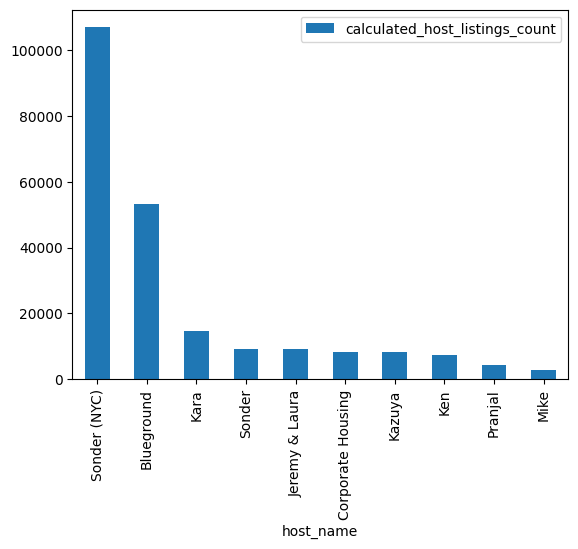

In [16]:
host_listings.plot(kind='bar', x='host_name', y='calculated_host_listings_count')
plt.show()

<Axes: xlabel='price', ylabel='number_of_reviews'>

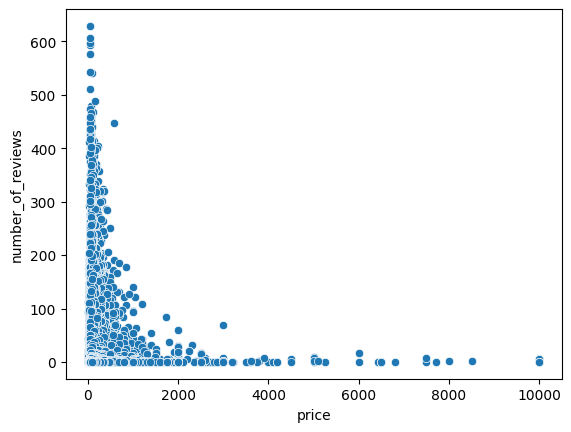

In [17]:
sns.scatterplot(x='price', y='number_of_reviews', data=df)

<Axes: xlabel='minimum_nights', ylabel='number_of_reviews'>

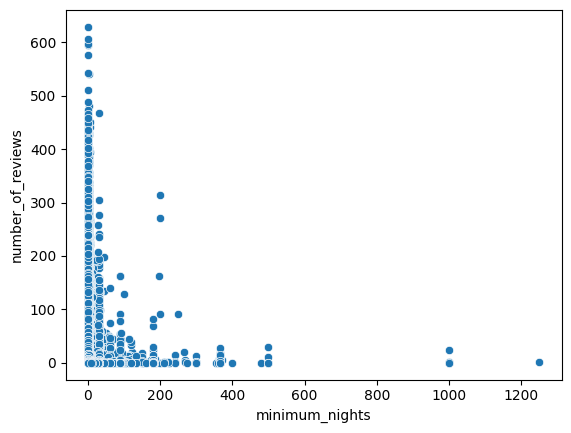

In [18]:
sns.scatterplot(x='minimum_nights', y='number_of_reviews', data=df)

<Axes: xlabel='minimum_nights', ylabel='price'>

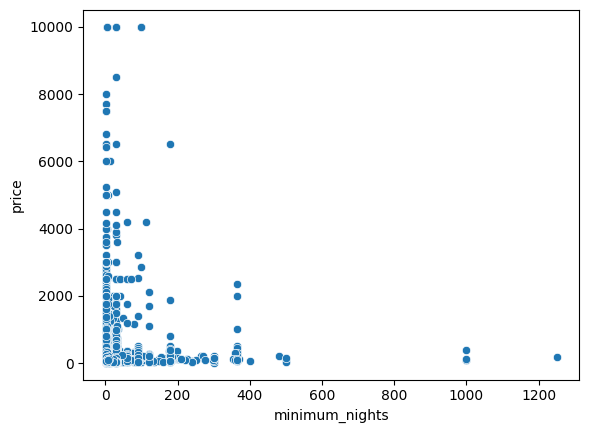

In [19]:
sns.scatterplot(x='minimum_nights', y='price', data=df)

<Axes: xlabel='calculated_host_listings_count', ylabel='number_of_reviews'>

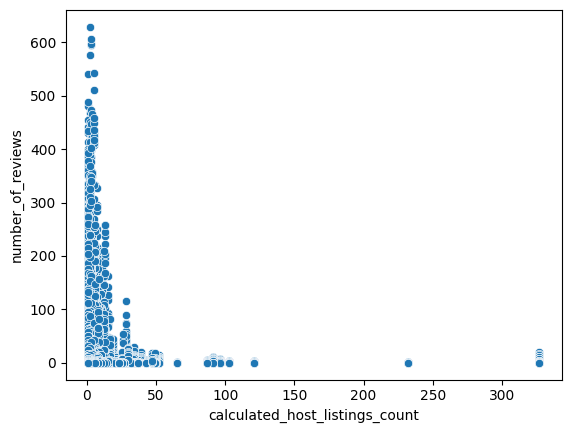

In [20]:
sns.scatterplot(x='calculated_host_listings_count', y='number_of_reviews', data=df)

<Axes: xlabel='calculated_host_listings_count', ylabel='price'>

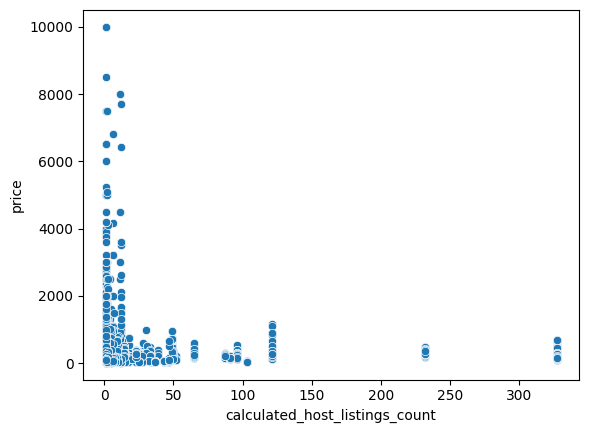

In [21]:
sns.scatterplot(x='calculated_host_listings_count', y='price', data=df)

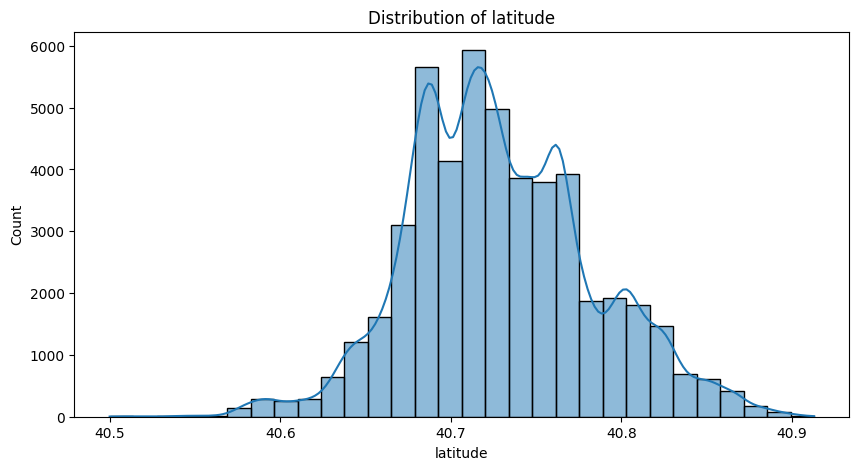

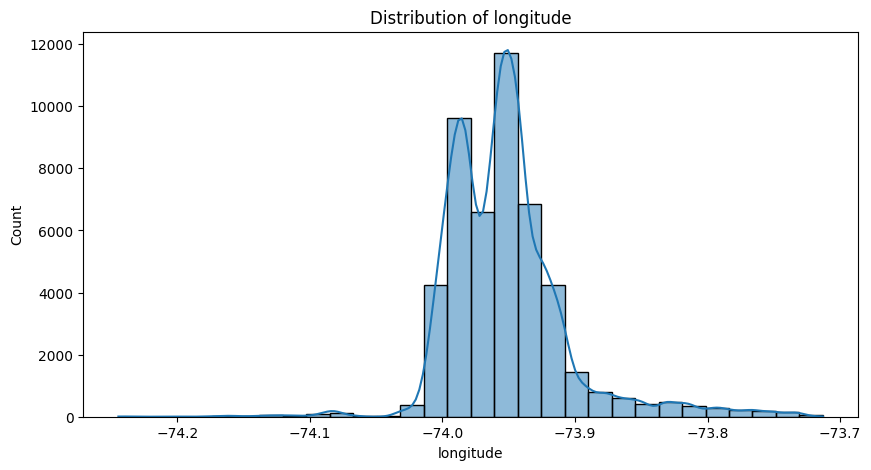

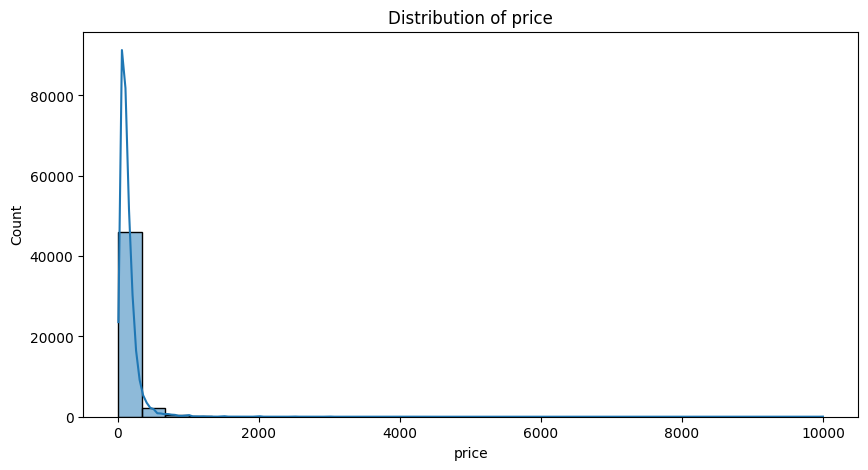

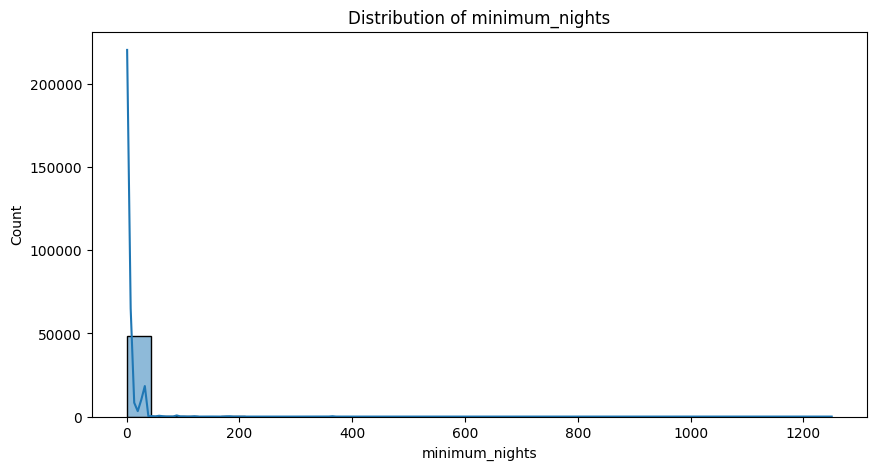

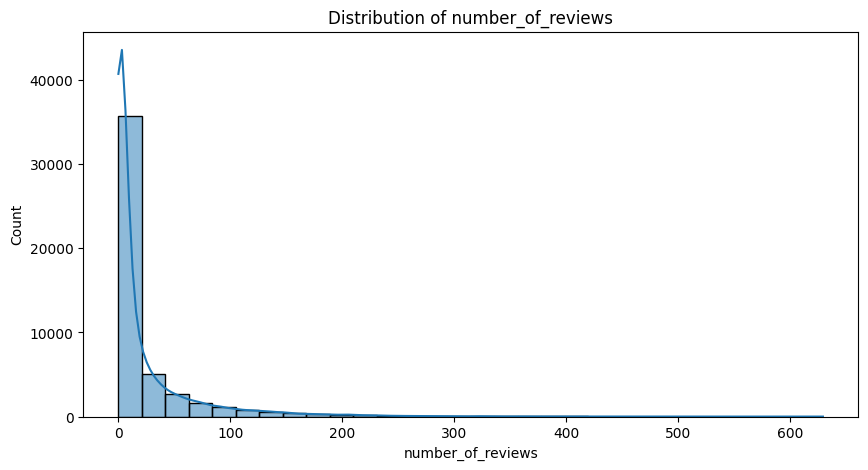

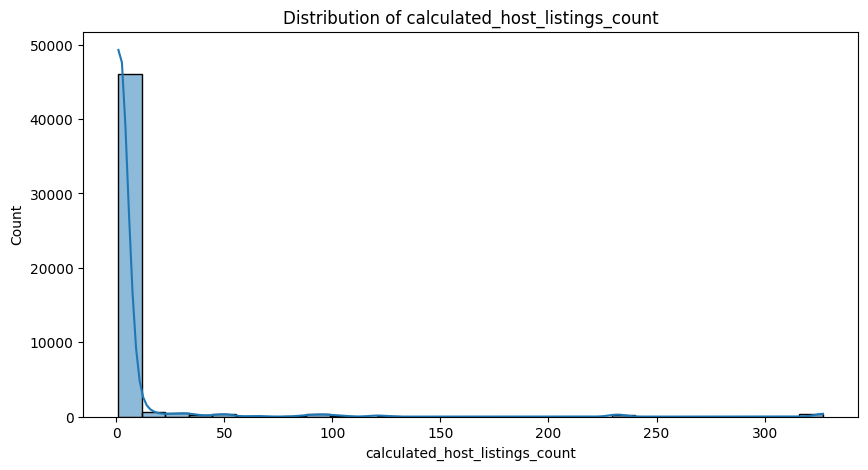

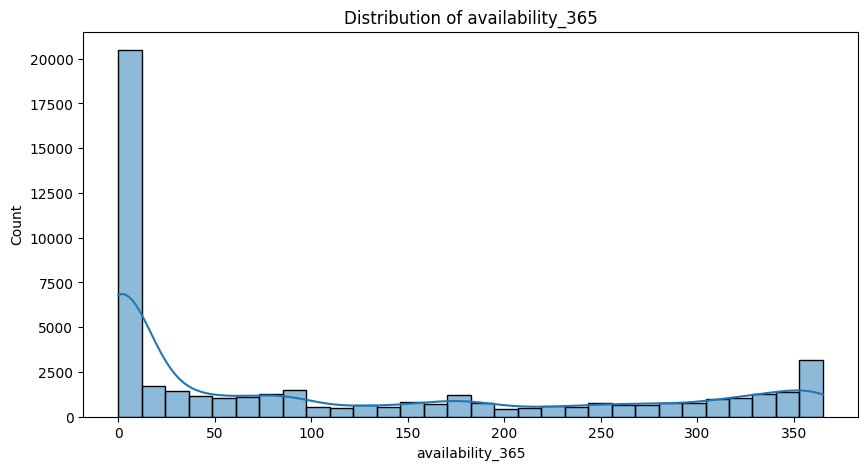

In [22]:
num_columns = df.select_dtypes(include=np.number).columns
for col in num_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [23]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

<Axes: xlabel='neighbourhood_group', ylabel='price'>

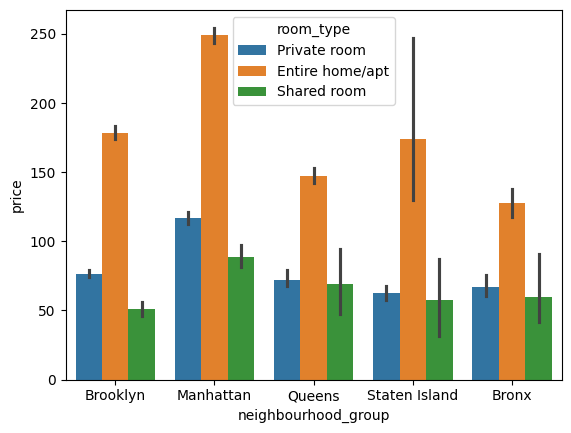

In [24]:
sns.barplot(x='neighbourhood_group', y='price', data=df, hue='room_type')

In [25]:
manhattan_df = df[df['neighbourhood_group'] == 'Manhattan']
manhattan_df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225.0,1,45,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150.0,3,0,1,365
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80.0,10,9,1,0
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200.0,3,74,1,129
7,Large Furnished Room Near B'way,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79.0,2,430,1,220
...,...,...,...,...,...,...,...,...,...,...,...,...
48886,Comfy 1 Bedroom in Midtown East,Scott,Manhattan,Midtown,40.75561,-73.96723,Entire home/apt,200.0,6,0,1,176
48888,"Spacious Room w/ Private Rooftop, Central loca...",Kat,Manhattan,Hell's Kitchen,40.76392,-73.99183,Private room,125.0,4,0,1,31
48892,Sunny Studio at Historical Neighborhood,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115.0,10,0,1,27
48893,43rd St. Time Square-cozy single bed,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55.0,1,0,6,2


In [26]:
manhattan_df['price'].describe()

count    21661.000000
mean       196.884631
std        291.380115
min         10.000000
25%         95.000000
50%        150.000000
75%        220.000000
max      10000.000000
Name: price, dtype: float64

In [27]:
q1_manhattan = manhattan_df['price'].quantile(0.25)
q3_manhattan = manhattan_df['price'].quantile(0.75)
iqr_manhattan = q3_manhattan - q1_manhattan
lower_bound_manhattan = q1_manhattan - 1.5 * iqr_manhattan
upper_bound_manhattan = q3_manhattan + 1.5 * iqr_manhattan
print(f"Lower bound for outliers in Manhattan: {lower_bound_manhattan}")
print(f"Upper bound for outliers in Manhattan: {upper_bound_manhattan}")

Lower bound for outliers in Manhattan: -92.5
Upper bound for outliers in Manhattan: 407.5


In [28]:
manhattan_over_400=manhattan_df[manhattan_df['price'] > 407]
percentage_manhattan = (len(manhattan_over_400) / len(manhattan_df)) * 100
print(f"Percentage of listings in Manhattan with price over $407: {percentage_manhattan:.2f}%")

Percentage of listings in Manhattan with price over $407: 5.95%


In [29]:
value_manhattan=manhattan_over_400['room_type'].value_counts()
percentage_manhattan = value_manhattan / value_manhattan.sum() * 100
percentage_manhattan

room_type
Entire home/apt    87.975175
Private room       11.559348
Shared room         0.465477
Name: count, dtype: float64

In [30]:
brooklyn_df = df[df['neighbourhood_group'] == 'Brooklyn']
brooklyn_df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149.0,1,9,6,365
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89.0,1,270,1,194
6,BlissArtsSpace!,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60.0,45,49,1,0
12,"Lovely Room 1, Garden, Best Area, Legal rental",Laurie,Brooklyn,South Slope,40.66829,-73.98779,Private room,89.0,4,167,3,314
15,Only 2 stops to Manhattan studio,Allen & Irina,Brooklyn,Williamsburg,40.70837,-73.95352,Entire home/apt,140.0,2,148,1,46
...,...,...,...,...,...,...,...,...,...,...,...,...
48882,Bushwick _ Myrtle-Wyckoff,Luisa,Brooklyn,Bushwick,40.69652,-73.91079,Private room,40.0,20,0,1,31
48884,Brooklyn Oasis in the heart of Williamsburg,Jonathan,Brooklyn,Williamsburg,40.71790,-73.96238,Private room,190.0,7,0,1,341
48887,Garden Jewel Apartment in Williamsburg New York,Melki,Brooklyn,Williamsburg,40.71232,-73.94220,Entire home/apt,170.0,1,0,3,365
48890,Charming one bedroom - newly renovated rowhouse,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70.0,2,0,2,9


In [31]:
manhattan_df['price'].describe()

count    21661.000000
mean       196.884631
std        291.380115
min         10.000000
25%         95.000000
50%        150.000000
75%        220.000000
max      10000.000000
Name: price, dtype: float64

In [32]:
q1_brooklyn = brooklyn_df['price'].quantile(0.25)
q3_brooklyn = brooklyn_df['price'].quantile(0.75)
iqr_brooklyn = q3_brooklyn - q1_brooklyn
lower_bound_brooklyn = q1_brooklyn - 1.5 * iqr_brooklyn
upper_bound_brooklyn = q3_brooklyn + 1.5 * iqr_brooklyn
print(f"Lower bound for outliers in Brooklyn: {lower_bound_brooklyn}")
print(f"Upper bound for outliers in Brooklyn: {upper_bound_brooklyn}")

Lower bound for outliers in Brooklyn: -75.0
Upper bound for outliers in Brooklyn: 285.0


In [33]:
brooklyn_over_400=brooklyn_df[brooklyn_df['price'] > 285]
percentage_brooklyn = (len(brooklyn_over_400) / len(brooklyn_df)) * 100
print(f"Percentage of listings in Brooklyn with price over $285: {percentage_brooklyn:.2f}%")

Percentage of listings in Brooklyn with price over $285: 4.95%


In [34]:
value_brooklyn=brooklyn_over_400['room_type'].value_counts()
percentage_brooklyn = value_brooklyn / value_brooklyn.sum() * 100
percentage_brooklyn

room_type
Entire home/apt    91.465863
Private room        8.232932
Shared room         0.301205
Name: count, dtype: float64

<Axes: xlabel='neighbourhood_group', ylabel='number_of_reviews'>

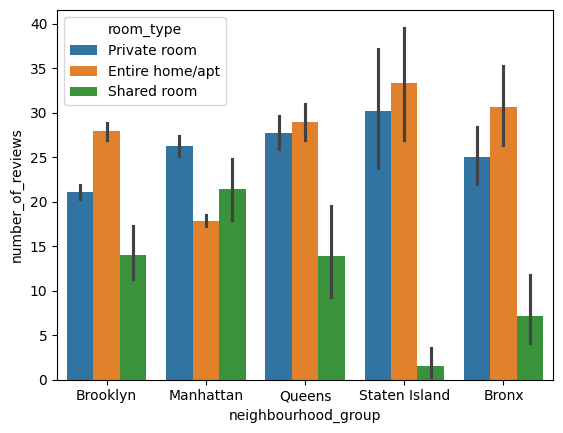

In [35]:
sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df, hue='room_type')

In [36]:
staten_island_df = df[df['neighbourhood_group'] == 'Staten Island']
staten_island_df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
169,New York room with a view,Newyorkroomwithaview,Staten Island,St. George,40.64524,-74.08088,Private room,70.0,2,166,1,312
249,A SpeciaL!! Private Room in NY,Lissette,Staten Island,Tompkinsville,40.63536,-74.08537,Private room,36.0,2,193,6,360
250,B NYC Staten Alternative...,Lissette,Staten Island,Tompkinsville,40.63627,-74.08543,Private room,37.0,2,147,6,0
251,C Private Room By The Ferry,Lissette,Staten Island,Tompkinsville,40.63518,-74.08546,Private room,37.0,2,177,6,320
256,D Private Che@p Room 2 Explore NYC,Lissette,Staten Island,Tompkinsville,40.63481,-74.08519,Private room,36.0,2,333,6,340
...,...,...,...,...,...,...,...,...,...,...,...,...
48441,A Home Away From Home,Jeannie,Staten Island,New Dorp Beach,40.56506,-74.10240,Private room,40.0,1,0,2,341
48446,"Beautiful home on Staten Island, walk to ferry",Janine,Staten Island,St. George,40.64005,-74.07987,Entire home/apt,100.0,365,0,1,342
48533,Staten Island Resort minutes from ferry! Amazi...,Danielle,Staten Island,Stapleton,40.62878,-74.07301,Entire home/apt,450.0,5,0,1,88
48649,PRIVATE ROOM IN STATEN ISLAND -FOR LADIES ONLY,Tuana,Staten Island,Shore Acres,40.61283,-74.06625,Private room,54.0,4,0,1,89


In [37]:
staten_island_df['number_of_reviews'].describe()

count    373.000000
mean      30.941019
std       44.830766
min        0.000000
25%        1.000000
50%       12.000000
75%       42.000000
max      333.000000
Name: number_of_reviews, dtype: float64

In [38]:
q1_staten_island = staten_island_df['number_of_reviews'].quantile(0.25)
q3_staten_island = staten_island_df['number_of_reviews'].quantile(0.75)
iqr_staten_island = q3_staten_island - q1_staten_island
lower_bound_staten_island = q1_staten_island - 1.5 * iqr_staten_island
upper_bound_staten_island = q3_staten_island + 1.5 * iqr_staten_island
print(f"Lower bound for outliers in Staten Island: {lower_bound_staten_island}")
print(f"Upper bound for outliers in Staten Island: {upper_bound_staten_island}")

Lower bound for outliers in Staten Island: -60.5
Upper bound for outliers in Staten Island: 103.5


In [39]:
staten_island_over_103=staten_island_df[staten_island_df['number_of_reviews'] > 103]
percentage_staten_island = (len(staten_island_over_103) / len(staten_island_df)) * 100
print(f"Percentage of listings in Staten Island with number of reviews over 103: {percentage_staten_island:.2f}%")

Percentage of listings in Staten Island with number of reviews over 103: 7.77%


In [40]:
value_s=staten_island_over_103['room_type'].value_counts()
percentage_staten_island= value_s / value_s.sum() * 100
percentage_staten_island

room_type
Entire home/apt    58.62069
Private room       41.37931
Name: count, dtype: float64

In [41]:
bronx_df = df[df['neighbourhood_group'] == 'Bronx']
bronx_df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
171,Room with a View,Waundell,Bronx,Highbridge,40.83232,-73.93184,Private room,40.0,1,219,3,353
207,Cozy bedroom by Yankee Stadium,Waundell,Bronx,Highbridge,40.83075,-73.93058,Private room,45.0,1,138,3,323
260,LL3,Carol Gloria,Bronx,Clason Point,40.81309,-73.85514,Private room,90.0,2,0,7,349
261,DOMINIQUE'S NY mini efficiency* wifi*metro*quiet,Vie,Bronx,Eastchester,40.88057,-73.83572,Entire home/apt,105.0,2,38,13,365
309,Condo Apartment with laundry in unit,Thai,Bronx,Kingsbridge,40.87207,-73.90193,Entire home/apt,90.0,30,4,2,346
...,...,...,...,...,...,...,...,...,...,...,...,...
48783,Best room in nyc,Jay,Bronx,Claremont Village,40.83926,-73.91173,Private room,140.0,1,0,1,90
48792,Private house Apartment,Carolina,Bronx,Morrisania,40.83146,-73.89666,Entire home/apt,80.0,7,0,1,71
48795,Cute double room for the perfect Yankee fan,Dominique,Bronx,Claremont Village,40.83502,-73.91058,Private room,125.0,2,0,1,364
48796,1A. Studio & Stay. 30 minutes to Midtown Manha...,Chantal,Bronx,Concourse Village,40.83372,-73.91187,Private room,70.0,2,0,2,81


In [42]:
bronx_df['number_of_reviews'].describe()

count    1091.000000
mean       26.004583
std        42.214774
min         0.000000
25%         1.000000
50%         9.000000
75%        32.000000
max       321.000000
Name: number_of_reviews, dtype: float64

In [43]:
q1_bronx = bronx_df['number_of_reviews'].quantile(0.25)
q3_bronx = bronx_df['number_of_reviews'].quantile(0.75)
iqr_bronx = q3_bronx - q1_bronx
lower_bound_bronx = q1_bronx - 1.5 * iqr_bronx
upper_bound_bronx = q3_bronx + 1.5 * iqr_bronx
print(f"Lower bound: {lower_bound_bronx}, Upper bound: {upper_bound_bronx}")

Lower bound: -45.5, Upper bound: 78.5


In [44]:
bronx_df[bronx_df['number_of_reviews'] > 78]

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
171,Room with a View,Waundell,Bronx,Highbridge,40.83232,-73.93184,Private room,40.0,1,219,3,353
207,Cozy bedroom by Yankee Stadium,Waundell,Bronx,Highbridge,40.83075,-73.93058,Private room,45.0,1,138,3,323
433,Artsy 1 bedroom Apt. 20 min to 42nd Grand Cent...,"Dee, Dre & Mama Shelley",Bronx,Woodlawn,40.89747,-73.86390,Entire home/apt,77.0,1,197,1,309
484,Affordable & Cozy,Vanessa,Bronx,University Heights,40.85811,-73.90675,Private room,37.0,4,117,1,232
510,A PRIVATE FLAT / APARTMENT- $SPECIAL$,Christian & Carla,Bronx,Allerton,40.86466,-73.85709,Entire home/apt,125.0,2,271,2,347
...,...,...,...,...,...,...,...,...,...,...,...,...
29178,Forest Houses City Getaway (No Hot Water),Mandela,Bronx,Longwood,40.82300,-73.90859,Entire home/apt,60.0,1,104,1,365
30008,"NO EXTRA FEES, NO MIN. NITES: 1.5 blocks to t...",Shera,Bronx,Woodlawn,40.89870,-73.86389,Private room,29.0,1,81,4,192
30488,Bronx Cozy 1 Bedroom Apartment with entire acc...,Milton,Bronx,Williamsbridge,40.87021,-73.86095,Entire home/apt,85.0,2,83,1,329
30579,LATE CHECK IN DISCOUNT! NO CLEANING FEE! 2/5 t...,Shera,Bronx,Woodlawn,40.89873,-73.86449,Private room,34.0,1,122,4,5


In [45]:
value_bronx= bronx_df['room_type'].value_counts()
percentage_bronx = value_bronx / value_bronx.sum() * 100
percentage_bronx

room_type
Private room       59.761687
Entire home/apt    34.738772
Shared room         5.499542
Name: count, dtype: float64

In [46]:
queens_df = df[df['neighbourhood_group'] == 'Queens']
queens_df

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
46,"1 Stop fr. Manhattan! Private Suite,Landmark B...",Orestes,Queens,Long Island City,40.74771,-73.94740,Private room,130.0,3,248,1,215
77,Little King of Queens,Justin,Queens,Woodside,40.75038,-73.90334,Private room,70.0,30,25,1,324
143,Fully Furnished Basement Apartment,Fredah,Queens,Flushing,40.74028,-73.83168,Private room,140.0,2,1,1,1
161,"A room w/ a Manhattan view, longer stay",Myung,Queens,Sunnyside,40.74559,-73.92313,Private room,79.0,30,28,1,126
181,Beautiful Queens Brownstone! - 5BR,Mark,Queens,Ridgewood,40.70382,-73.89797,Entire home/apt,350.0,8,10,5,365
...,...,...,...,...,...,...,...,...,...,...,...,...
48858,"2beds Private Room Step to LGA, CitiFiled, Mid...",Marvy,Queens,Flushing,40.74387,-73.82556,Private room,68.0,3,0,4,362
48863,Comfortable & Big room with 2 beds!,Stefan,Queens,Long Island City,40.76726,-73.93936,Private room,93.0,2,0,2,14
48866,CozyHideAway Suite,Alberth,Queens,Briarwood,40.70786,-73.81448,Entire home/apt,58.0,1,0,1,159
48878,Room for rest,Jeerathinan,Queens,Elmhurst,40.74477,-73.87727,Private room,45.0,1,0,5,172


In [47]:
q1_queens = queens_df['number_of_reviews'].quantile(0.25)
q3_queens = queens_df['number_of_reviews'].quantile(0.75)
iqr_queens = q3_queens - q1_queens
lower_bound_queens = q1_queens - 1.5 * iqr_queens
upper_bound_queens = q3_queens + 1.5 * iqr_queens
print(f"Lower bound: {lower_bound_queens}, Upper bound: {upper_bound_queens}")

Lower bound: -45.5, Upper bound: 78.5


In [48]:
queens_df[queens_df['number_of_reviews'] > 78]

,name,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
46,"1 Stop fr. Manhattan! Private Suite,Landmark B...",Orestes,Queens,Long Island City,40.74771,-73.94740,Private room,130.0,3,248,1,215
257,Safe cute near subway& Manhattan NY NY retro s...,Dennis & Naoko,Queens,Astoria,40.75384,-73.91433,Entire home/apt,99.0,5,441,1,226
316,One Bedroom Mini studio - Free WIFI,Nazleen,Queens,Astoria,40.77635,-73.93426,Entire home/apt,115.0,2,198,1,257
435,Astoria-Private Home NYC-,Gladys & Bob,Queens,Astoria,40.75725,-73.91098,Entire home/apt,129.0,1,414,1,245
530,"Spacious, Kid-Friendly, and 15-20 Mins. to Mid...",Mike,Queens,Sunnyside,40.74249,-73.92466,Private room,75.0,2,160,1,65
...,...,...,...,...,...,...,...,...,...,...,...,...
37652,Cozy 1 bedroom Apartment 5 min from LGA!,Melitza,Queens,East Elmhurst,40.76373,-73.86508,Entire home/apt,70.0,1,83,1,0
38592,Better Home Inn,Better Home,Queens,Springfield Gardens,40.66272,-73.76849,Entire home/apt,89.0,1,88,2,253
40025,6 minutes from JFK Private Bedroom/Bathroom,Lakshmee,Queens,Springfield Gardens,40.66670,-73.78469,Private room,100.0,1,86,8,335
40036,6 Minutes From JFK Airport Cozy Bedroom,Lakshmee,Queens,Jamaica,40.66800,-73.78477,Private room,30.0,1,98,8,189


In [49]:
value_queens= queens_df['room_type'].value_counts()
percentage_queens = value_queens / value_queens.sum() * 100
percentage_queens

room_type
Private room       59.512884
Entire home/apt    36.992587
Shared room         3.494529
Name: count, dtype: float64

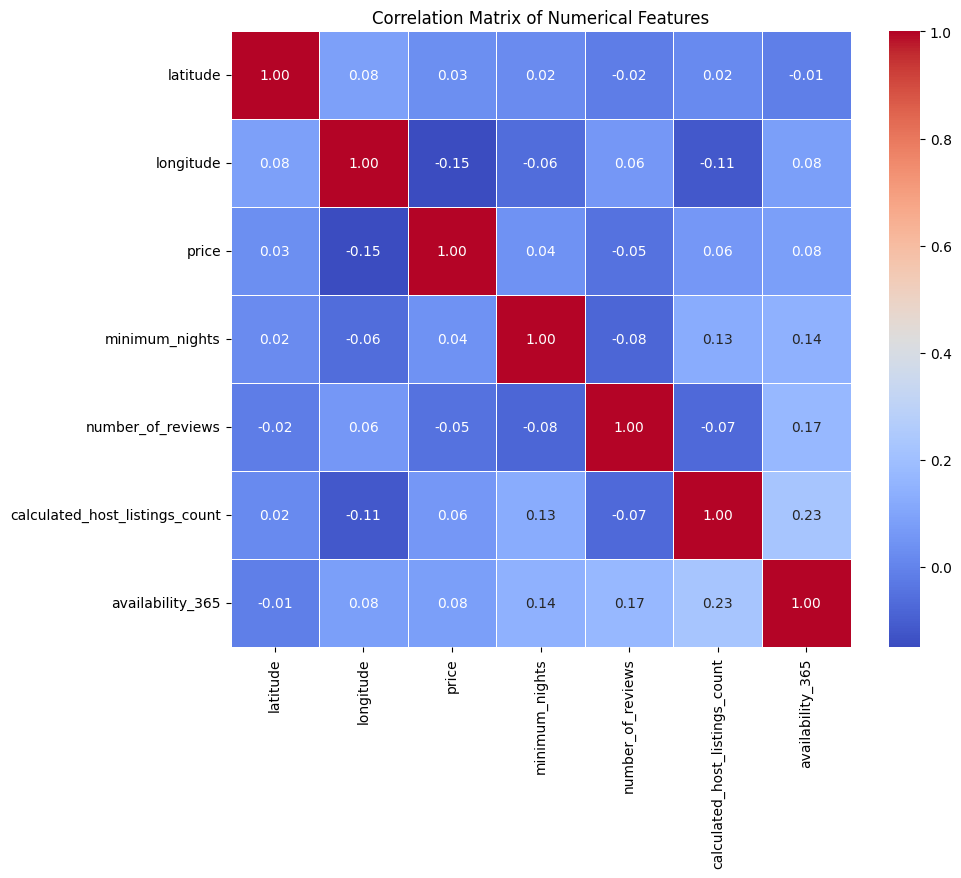

In [50]:
num_columns = df.select_dtypes(include=np.number).columns
corr_matrix = df[num_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

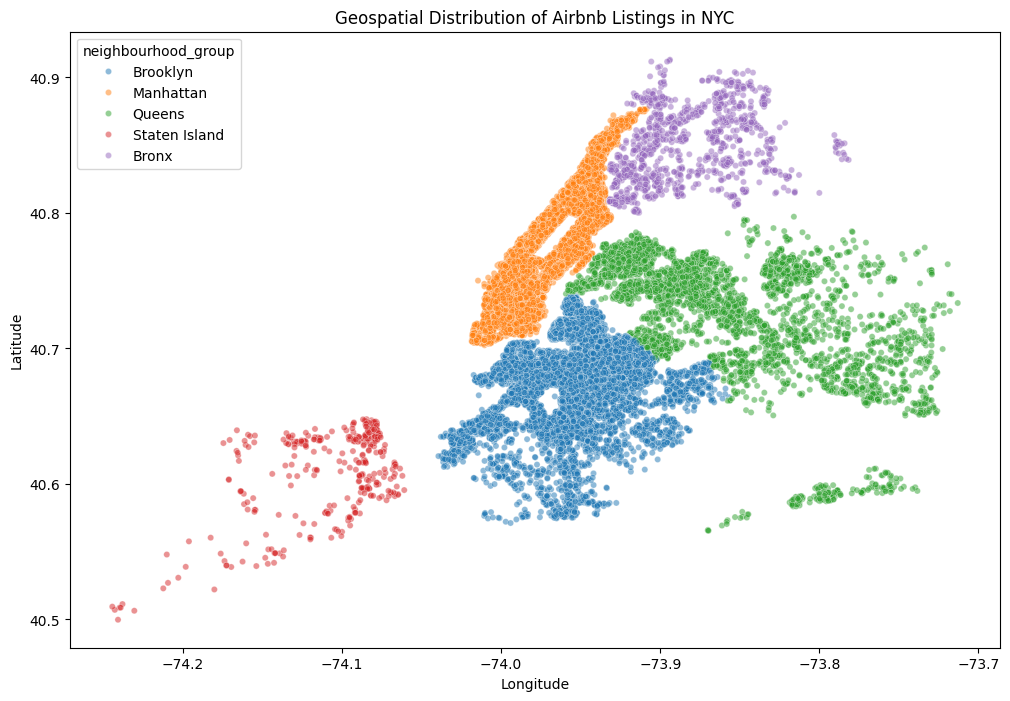

In [51]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    alpha=0.5,
    s=20
)

plt.title('Geospatial Distribution of Airbnb Listings in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')


plt.show()

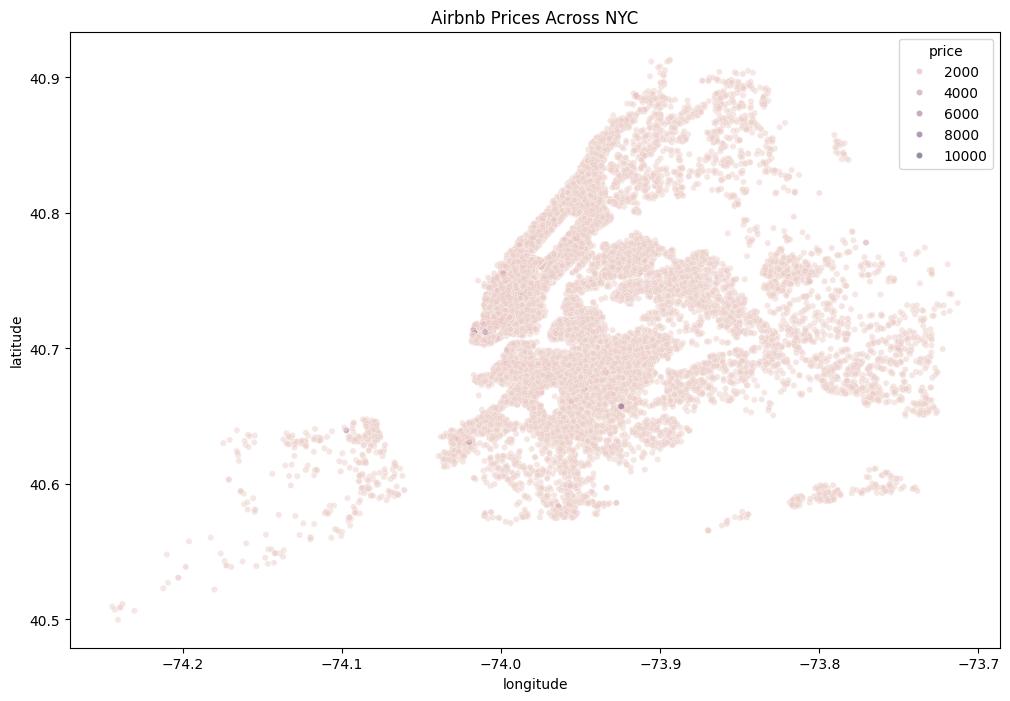

In [52]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='price',
    alpha=0.5,
    s=20
)

plt.title('Airbnb Prices Across NYC')
plt.show()

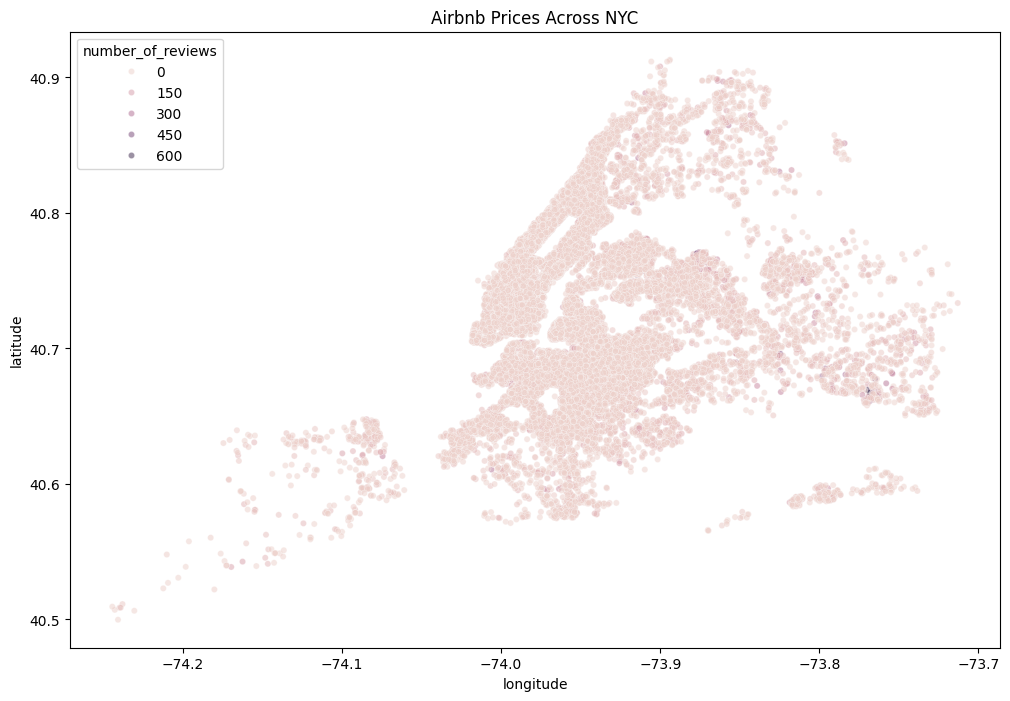

In [53]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='number_of_reviews',
    alpha=0.5,
    s=20
)

plt.title('Airbnb Prices Across NYC')
plt.show()

<Figure size 1200x800 with 0 Axes>

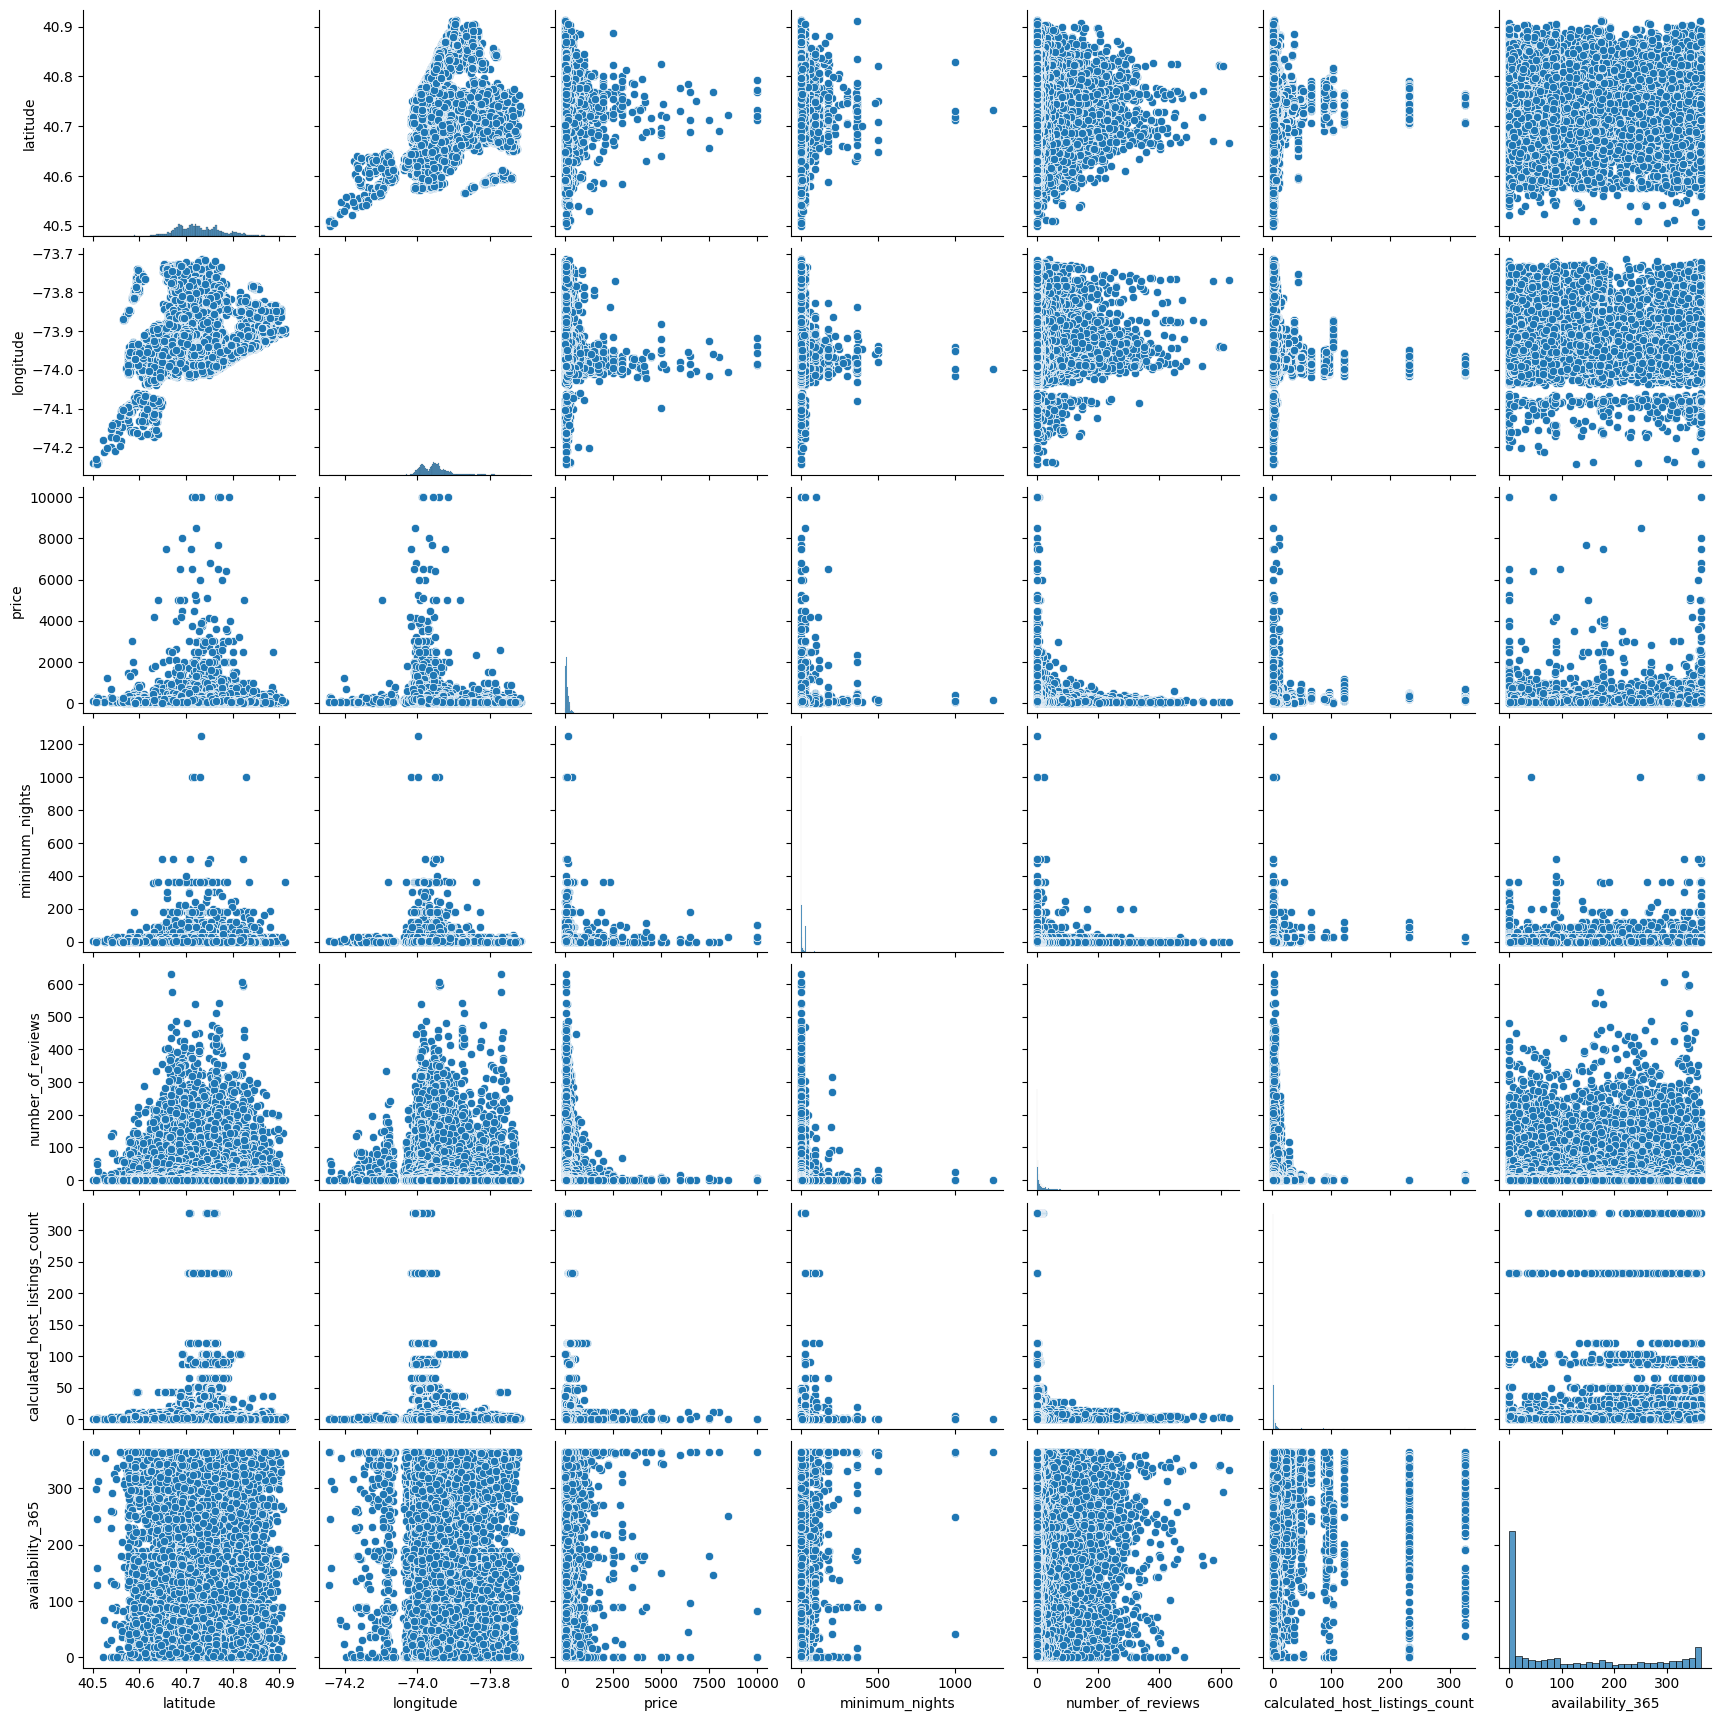

In [54]:
plt.figure(figsize=(12,8))
sns.pairplot(df[num_columns])
plt.show()

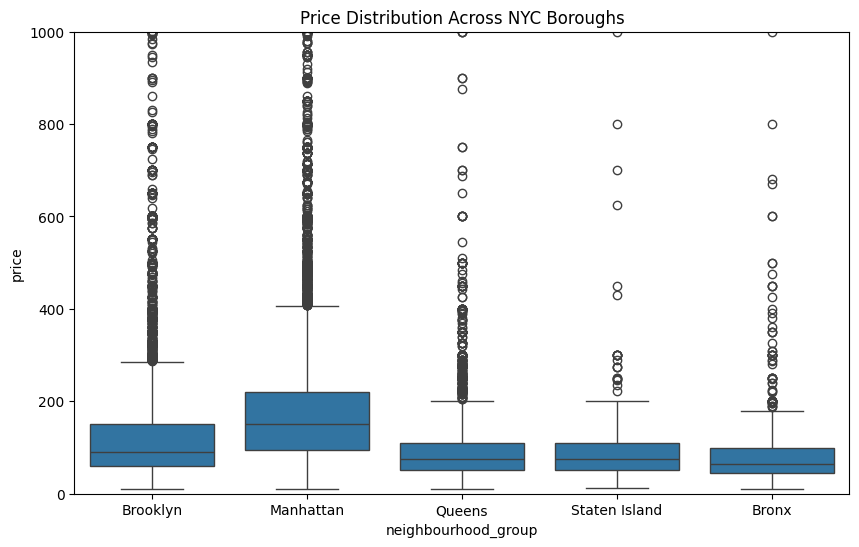

In [55]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='neighbourhood_group',
    y='price'
)

plt.ylim(0,1000)

plt.title('Price Distribution Across NYC Boroughs')

plt.show()

In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
df['log_price'] = np.log1p(df['price'])
model = smf.ols(
    'log_price ~ neighbourhood_group + room_type + availability_365 + minimum_nights + number_of_reviews',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     4859.
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        21:02:38   Log-Likelihood:                -35740.
No. Observations:               48895   AIC:                         7.150e+04
Df Residuals:                   48885   BIC:                         7.159e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [57]:
coef = model.params
percent_effect = np.exp(coef) - 1
percent_effect * 100

Intercept                               10875.548895
neighbourhood_group[T.Brooklyn]            28.884930
neighbourhood_group[T.Manhattan]           77.347191
neighbourhood_group[T.Queens]              12.520970
neighbourhood_group[T.Staten Island]       -0.142964
room_type[T.Private room]                 -53.949959
room_type[T.Shared room]                  -68.724356
availability_365                            0.071649
minimum_nights                             -0.174054
number_of_reviews                          -0.082067
dtype: float64

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['availability_365',
        'minimum_nights',
        'number_of_reviews',
        'calculated_host_listings_count']]

X = sm.add_constant(X)

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

                         Variable       VIF
0                           const  1.950902
1                availability_365  1.115538
2                  minimum_nights  1.041226
3               number_of_reviews  1.054508
4  calculated_host_listings_count  1.076270
